In [1]:
import sys
sys.path.append("..")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from DicomToNumpyClass import DicomToNumpy
from preprocessor.preprocessor import CTManager
from brain_extraction.brain_extractor import BrainExtractorManager
from kernel_extraction.kernel_extractor import KernelExtractorManager
processor = DicomToNumpy("../Brain_Stroke_CT_Dataset")
subdataset = processor.get_subset(limit = 1000) # tomo solo las 1000 primeras imágenes
subdataset_filtered = CTManager.process_batch_clean_image(subdataset)
subdataset_filtered = BrainExtractorManager(subdataset_filtered).extract_all_brains(plot_examples=False)
kernel_manager = KernelExtractorManager(subdataset_filtered, patch_size=32)
kernels_dataset = kernel_manager.extract_all(patches_per_lesion=3)

## Función para visualizar Boxplot de Features
Definición de plot_feature_distributions(df_features) para observar si la feature es significativa frente a las demás clases.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

def plot_feature_distributions(df):
    """
    Genera una grilla de boxplots para cada característica numérica en el DataFrame,
    separada y coloreada por clase (Normal, Bleeding, Ischemia).
    """
    print("Generando gráficos estadísticos...")
    
    # Extraemos todas las columnas que son características (ignoramos 'label')
    features = [col for col in df.columns if col != 'label']
    num_features = len(features)
    
    # Configuramos una grilla de 3 columnas y las filas necesarias
    cols = 3
    rows = math.ceil(num_features / cols)
    
    # Creamos la figura general
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    axes = axes.flatten() # Aplanamos el array de ejes para iterar fácil
    
    # Definimos colores fijos para no confundirnos visualmente
    palette_colors = {'Normal': '#2ca02c',     # Verde
                      'Bleeding': '#d62728',   # Rojo
                      'Ischemia': '#1f77b4'}   # Azul
    
    for i, feature in enumerate(features):
        # Ploteamos el boxplot
        sns.boxplot(
            data=df, 
            x='label', 
            y=feature, 
            ax=axes[i], 
            palette=palette_colors,
            hue='label', # Asignar el hue a la misma variable X evita warnings de seaborn
            legend=False
        )
        
        # Títulos y limpieza de ejes
        axes[i].set_title(f"Distribución: {feature}", fontsize=12, fontweight='bold')
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Valor")
        axes[i].grid(True, axis='y', alpha=0.3)
        
    # Si la grilla tiene huecos vacíos al final (ej. 14 features en 15 espacios), los borramos
    for j in range(num_features, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# --- EJEMPLO DE USO ---
# Simplemente llámalo pasándole tu DataFrame recién creado:
# plot_feature_distributions(df_features)

## Feature Extractor
Obtengo Kernels de 32x32 de cada tejido:
- Normal: proviene de 'brain' (tejido sano).
- Ischemia/Bleeding: proviene de 'overlay' (tejido no sano).

In [8]:
from feature_extraction.feature_extract import FeatureExtractManager

In [9]:
feature_manager = FeatureExtractManager(kernels_dataset)
df_features = feature_manager.extract_all_to_dataframe()

Iniciando extracción radiómica (First-Order, GLCM, LDOP-Gradients)...
  -> Minando características para clase: Bleeding (2884 parches)
  -> Minando características para clase: Ischemia (2884 parches)
  -> Minando características para clase: Normal (2884 parches)
--------------------------------------------------
EXTRACCIÓN COMPLETADA.
Dataset estructurado final: 8652 filas (ejemplos) x 15 columnas (features + label)
--------------------------------------------------


Generando gráficos estadísticos...


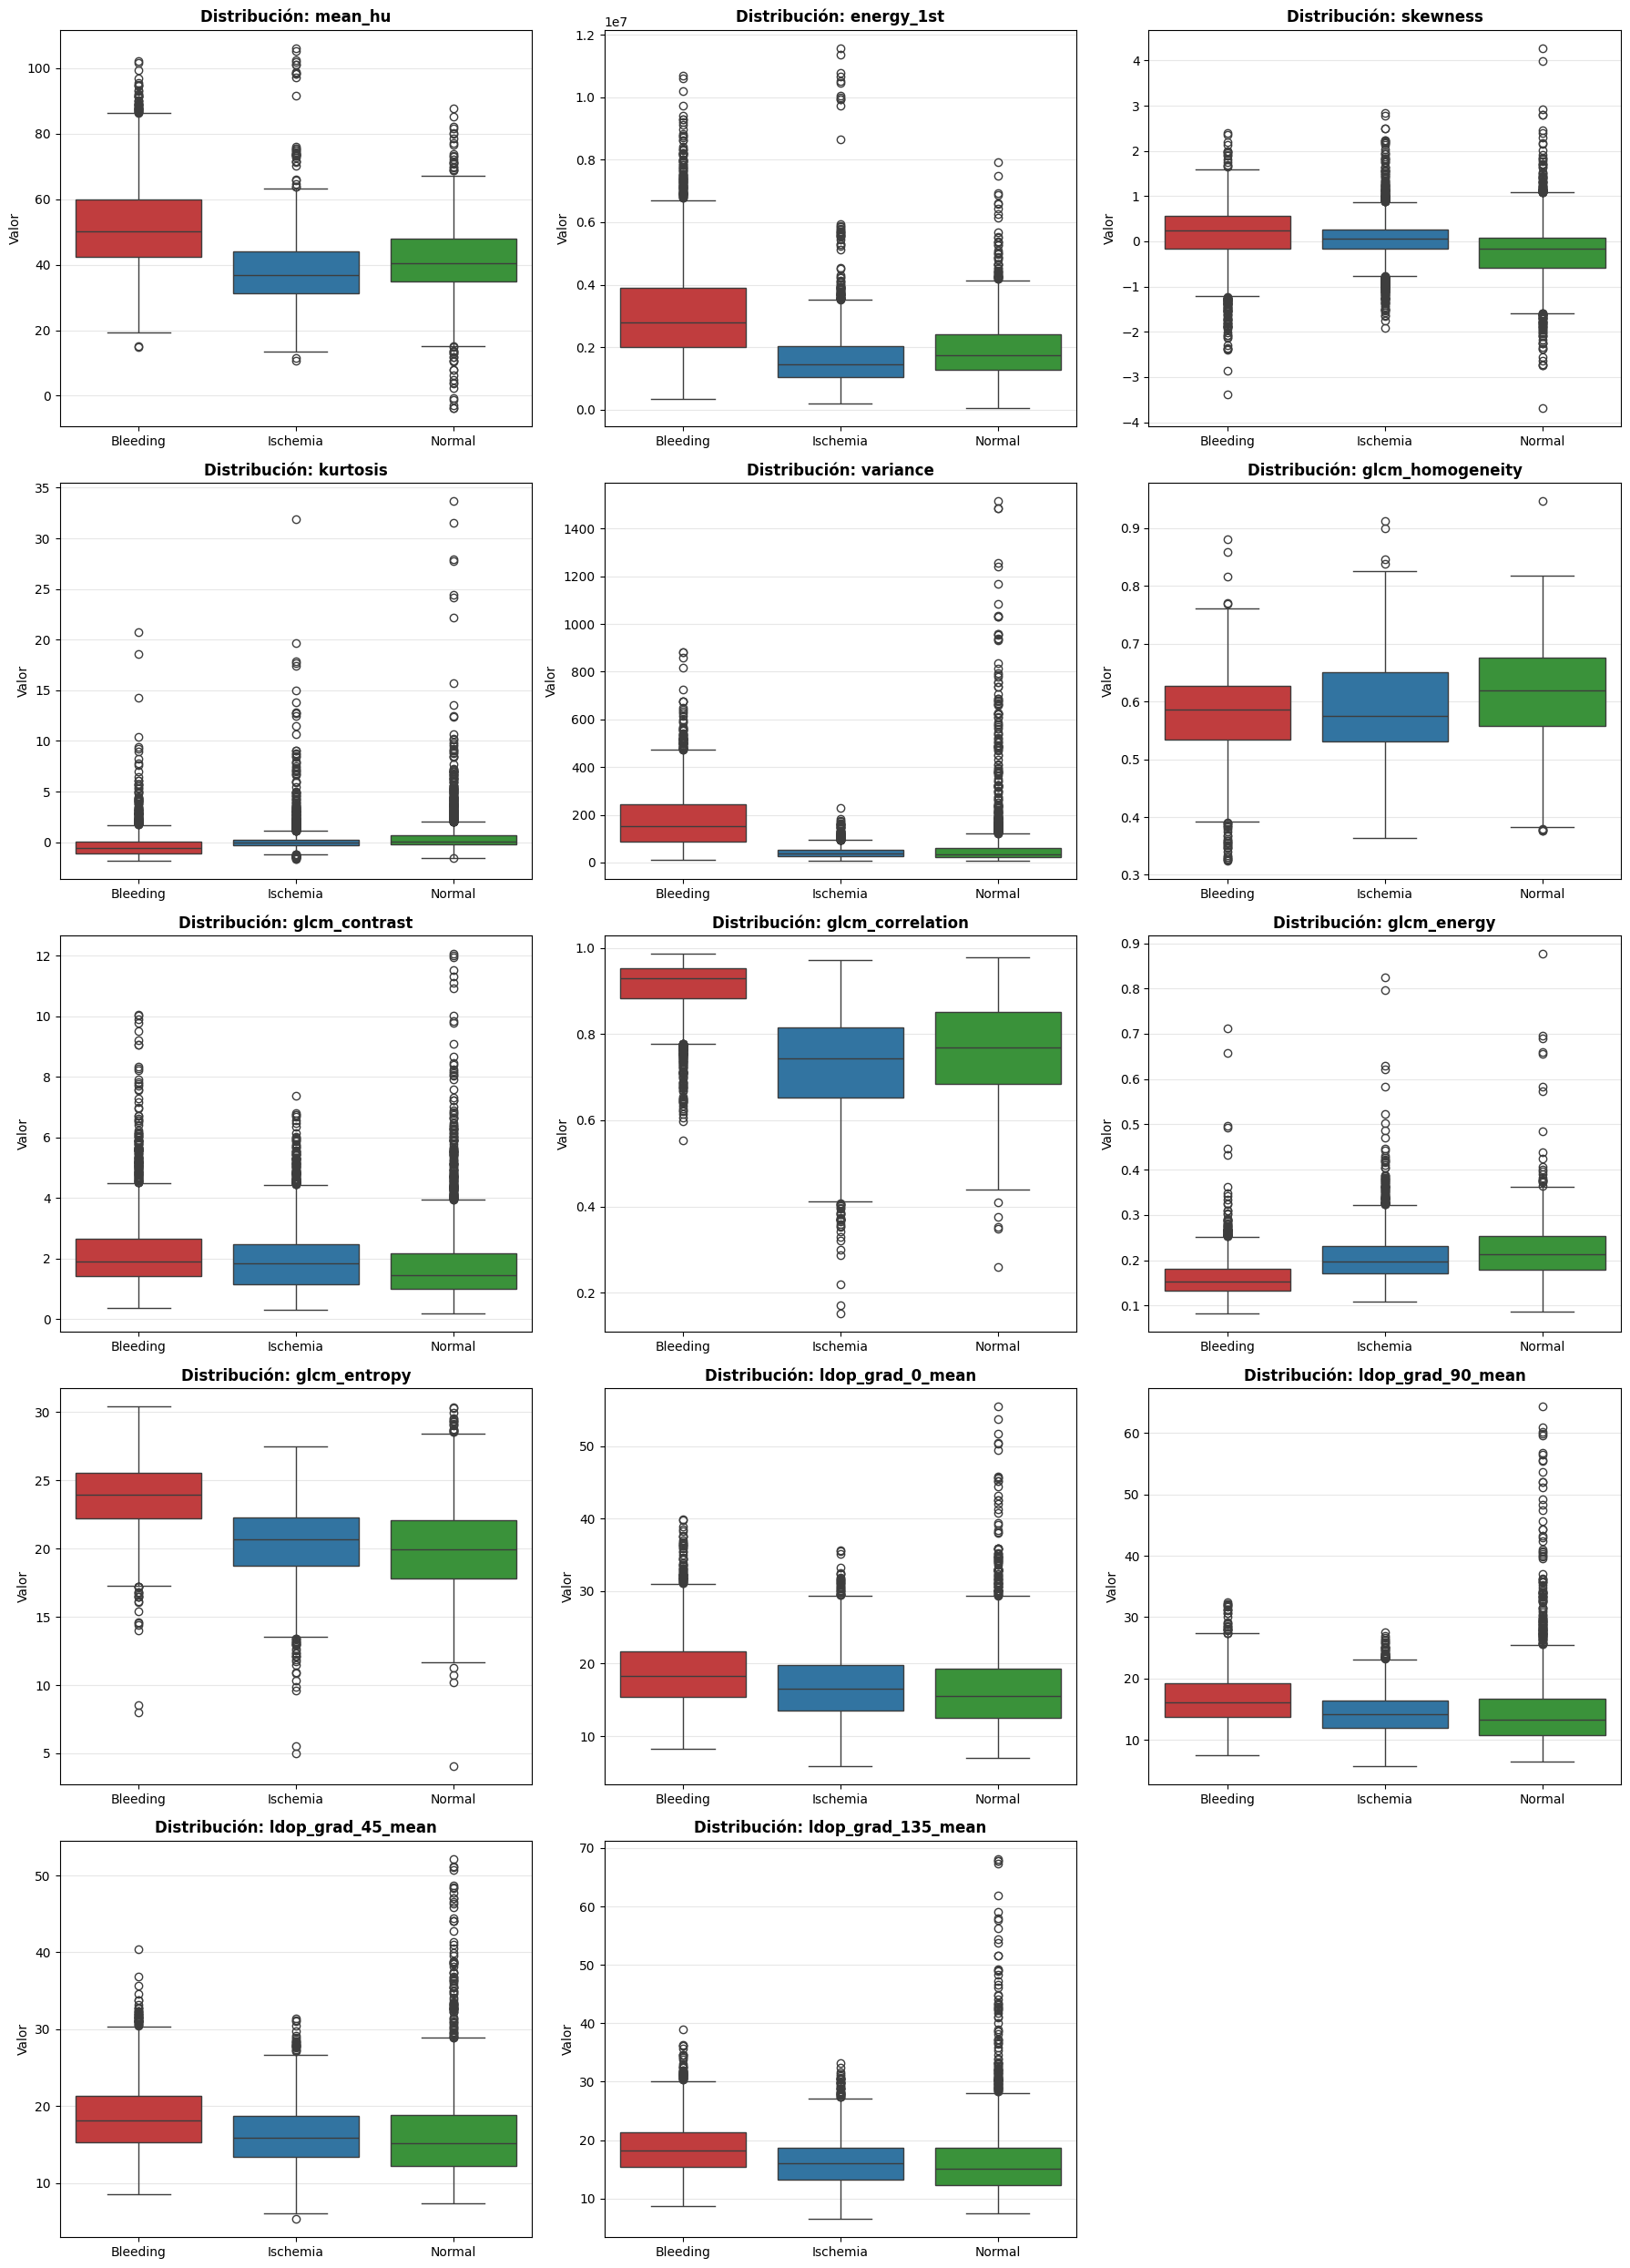

In [11]:
plot_feature_distributions(df_features)

# Almacenamiento del Kernel
Para no volver a correr los códigos para general los kernels (que lleva su tiempo) lo almaceno como NumPy.

#### Función

In [ ]:
import os
import numpy as np
from pathlib import Path

def save_kernels_dataset(kernels_dict, output_folder="../Kernels_datasets_numpy"):
    """
    Guarda el diccionario de kernels en la carpeta especificada, 
    creando archivos secuenciales (kernel_dataset_1.npy, kernel_dataset_2.npy, etc.)
    """
    folder_path = Path(output_folder)
    # Crea la carpeta si no existe
    folder_path.mkdir(parents=True, exist_ok=True)
    
    # Buscamos todos los archivos que coincidan con el patrón
    existing_files = list(folder_path.glob("kernel_dataset_*.npy"))
    
    max_num = 0
    for f in existing_files:
        try:
            # Extraemos el número del nombre del archivo
            # Ej: de "kernel_dataset_3.npy" sacamos el "3"
            num = int(f.stem.split('_')[-1])
            if num > max_num:
                max_num = num
        except ValueError:
            # Si hay un archivo mal nombrado, lo ignoramos
            continue
            
    next_num = max_num + 1
    save_path = folder_path / f"kernel_dataset_{next_num}.npy"
    
    # Guardamos el diccionario. Numpy requiere que lo tratemos como un array de objetos.
    np.save(save_path, kernels_dict)
    
    print("-" * 50)
    print(f"ÉXITO: Dataset de kernels guardado en '{save_path}'")
    print("-" * 50)
    
    return save_path

# --- EJEMPLO DE USO ---
# Simplemente llámalo pasándole tu diccionario generado por KernelExtractorManager
# ruta_guardada = save_kernels_dataset(kernels_dataset)

### 

In [ ]:
save_kernels_dataset(kernels_dataset)
# kernels_cargados = np.load("Kernels_datasets_numpy/kernel_dataset_1.npy", allow_pickle=True).item()

--------------------------------------------------
ÉXITO: Dataset de kernels guardado en 'Kernels_datasets_numpy\kernel_dataset_1.npy'
--------------------------------------------------


WindowsPath('Kernels_datasets_numpy/kernel_dataset_1.npy')

# Análisis de Características
Ahora analizo que features son mejores para entrenar al modelo.
- primero, a partir de un pequeño Random-Forest, veo que features tienen mejor Score.
- segundo, a partir de la correlación de Pearson, veo si hay features que brindan la misma información (lo que puede confundir al modelo).

#### Funciones

In [17]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

def rank_features_objectively(df):
    """
    Evalúa la importancia de cada característica usando Información Mutua 
    y un mini-modelo de Random Forest.
    """
    print("Analizando importancia de características...")
    
    # Separamos características (X) y etiquetas (y)
    X = df.drop('label', axis=1)
    y = df['label']

    # 1. Prueba Estadística: Información Mutua
    mi_scores = mutual_info_classif(X, y, random_state=42)

    # 2. Prueba Mini-Modelo: Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    rf_scores = rf.feature_importances_

    # 3. Consolidar en un DataFrame
    ranking = pd.DataFrame({
        'Caracteristica': X.columns,
        'Info_Mutua': mi_scores,
        'RF_Importancia': rf_scores
    })

    # Normalizamos ambos puntajes de 0 a 1 para poder promediarlos justamente
    ranking['MI_Norm'] = ranking['Info_Mutua'] / ranking['Info_Mutua'].max()
    ranking['RF_Norm'] = ranking['RF_Importancia'] / ranking['RF_Importancia'].max()
    
    # Calculamos un Score Final Promedio
    ranking['Score_Final'] = (ranking['MI_Norm'] + ranking['RF_Norm']) / 2

    # Ordenamos de mejor a peor
    ranking = ranking.sort_values(by='Score_Final', ascending=False).reset_index(drop=True)

    print("\n--- RANKING DEFINITIVO DE CARACTERÍSTICAS ---")
    print(ranking[['Caracteristica', 'Score_Final', 'Info_Mutua', 'RF_Importancia']])
    
    # Ploteo rápido del ranking
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Score_Final', y='Caracteristica', data=ranking, palette='viridis')
    plt.title('Importancia Global de Características (Mutual Info + Random Forest)')
    plt.xlabel('Score Combinado (Normalizado 0-1)')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

    return ranking

# --- EJEMPLO DE USO ---
# df_ranking = rank_features_objectively(df_features)

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation_matrix(df):
    """
    Genera un Heatmap de correlación de Pearson para detectar 
    características redundantes (clones matemáticos).
    """
    print("Calculando matriz de correlación cruzada...")
    
    # Quitamos la etiqueta de texto para poder hacer matemáticas
    df_numeric = df.drop('label', axis=1)
    
    # Calculamos la correlación
    corr_matrix = df_numeric.corr()
    
    # Configuramos el lienzo
    plt.figure(figsize=(14, 10))
    plt.title("Matriz de Correlación de Características (Buscando Redundancias)", fontsize=14)
    
    # Ploteamos el heatmap. 
    # vmin=-1 y vmax=1 son los límites matemáticos.
    # annot=True escribe el numerito adentro de cada cuadro.
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
                vmin=-1, vmax=1, square=True, linewidths=.5)
    
    plt.tight_layout()
    plt.show()

# --- EJEMPLO DE USO ---
# Pásale tu DataFrame de características:
# plot_correlation_matrix(df_features)

#### 

Analizando importancia de características...

--- RANKING DEFINITIVO DE CARACTERÍSTICAS ---
        Caracteristica  Score_Final  Info_Mutua  RF_Importancia
0             variance     1.000000    0.314981        0.123662
1     glcm_correlation     0.951788    0.285067        0.123482
2           energy_1st     0.624720    0.157984        0.092483
3              mean_hu     0.578559    0.139931        0.088154
4         glcm_entropy     0.570279    0.178684        0.070892
5             skewness     0.511823    0.092085        0.090433
6             kurtosis     0.502315    0.133763        0.071719
7          glcm_energy     0.480719    0.145342        0.061832
8   ldop_grad_135_mean     0.308454    0.076067        0.046424
9    ldop_grad_90_mean     0.298865    0.055521        0.052119
10   ldop_grad_45_mean     0.282588    0.065166        0.044306
11    glcm_homogeneity     0.268749    0.042474        0.049793
12       glcm_contrast     0.265437    0.051207        0.045545
13    ldop_g

C:\Users\lourd\AppData\Local\Temp\ipykernel_20308\3192512853.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score_Final', y='Caracteristica', data=ranking, palette='viridis')


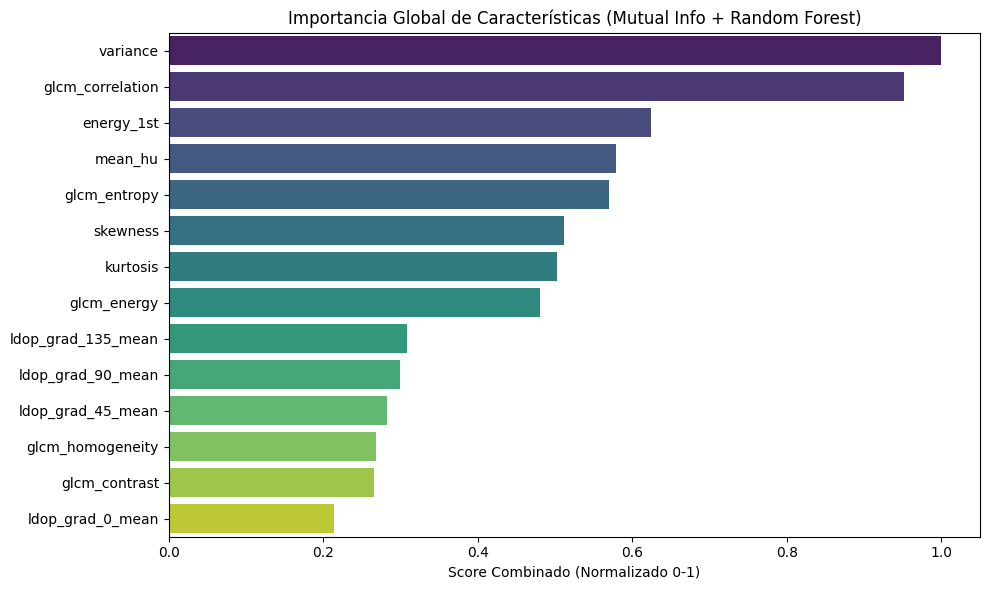

In [18]:
df_ranking = rank_features_objectively(df_features)

Calculando matriz de correlación cruzada...


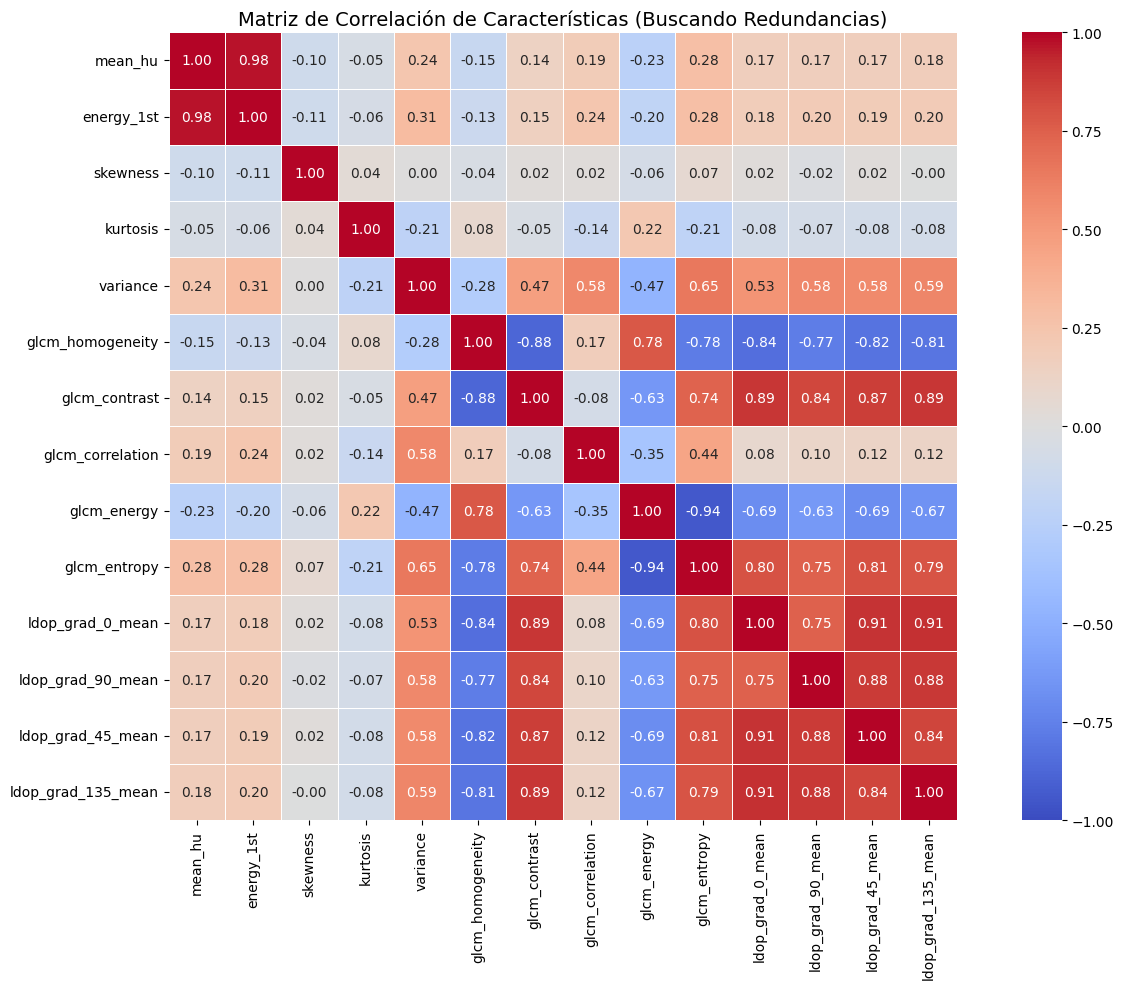

In [20]:
plot_correlation_matrix(df_features)